In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

In [2]:
import ee
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='mapbiomas-india')

In [3]:
import sys
sys.path.append('..')

In [4]:
territory_name = 'INDIA'

In [5]:
#  Annual mosaics for the territory.
mosaics_asset = 'projects/mapbiomas-mosaics/assets/LANDSAT/LULC/INDIA/mosaics-1';

# Path to the regions shapefile. Asset for India's 7 bio-geographicas zones, No changes required*
regions_asset = 'projects/mapbiomas-india/assets/ioln_classification_regions';

sample_folder = 'projects/mapbiomas-india/assets/LAND-COVER/COLLECTION-1/SAMPLES/';

Load all relevant data

In [6]:
classwise_samples_scaled_2k_10k = pd.read_csv('data/classwise_samples_scaled_2k_10k.csv')

In [7]:
classwise_samples_scaled_2k_10k.head()

,l2_code,l2_name,classification_class_code,HIM,IGP,DES,PEN,NEI,WGR,ICR
0,5,Mangrove Forest,5,0,0,0,0,0,0,297
1,3,Evergreen Forest,3,625,215,116,650,775,407,247
2,4,Deciduous Forest,4,425,431,566,1533,480,304,225
3,12,Grassland/ Herbaceous,12,555,431,694,1115,243,288,150
4,11,Wetlands & Marsh Lands,11,176,255,259,353,172,108,228


In [8]:
runs_analysis_df = pd.read_csv('data/groupwise_runs_default_and_scaled_samples.csv')

In [9]:
region_numbers_df = pd.read_csv('data/regions_area.csv')
region_numbers_df

,WKT,region_id,region_name,area_km2,area_ratio,region_code
0,"POLYGON ((76.45674224495308 31.18985484698067,...",1,himalayas,5.091073e+05,0.111852,HIM
1,POLYGON ((89.49476445416138 25.894434349807106...,2,indo-gangetic plains,7.431148e+05,0.163264,IGP
2,"POLYGON ((71.84823309904665 28.17975812425188,...",3,desert and arid central India,1.012130e+06,0.222367,DES
3,POLYGON ((74.02730496067635 16.295409208216387...,4,peninsula and east-central highlands,1.439745e+06,0.316316,PEN
4,MULTIPOLYGON (((88.53413707052863 28.180357486...,5,north-east hills,3.832771e+05,0.084207,NEI
5,POLYGON ((76.83831108113418 11.835744059378296...,6,western ghats,1.917050e+05,0.042118,WGR
6,MULTIPOLYGON (((92.36087732265902 11.598109838...,7,islands and coasts,2.725310e+05,0.059876,ICR


Train a classifier

In [10]:
runs_analysis_df.sort_values(by=['f1_weighted'], ascending=False).head(10)

,region,year,sample_version,sample_strategy,n_trees,features,accuracy,f1_weighted
22,DES,2018,7,scaled,50,all,0.957759,0.958016
14,IGP,2018,5,scaled,50,all,0.956117,0.954694
12,IGP,2018,5,scaled,10,all,0.952128,0.949540
20,DES,2018,7,scaled,10,all,0.943985,0.944398
10,IGP,2018,5,default,50,all,0.929368,0.929887
23,DES,2018,7,scaled,50,static_16,0.927456,0.927026
38,NEI,2018,5,scaled,50,all,0.923077,0.921961
54,ICR,2018,4,scaled,50,all,0.919492,0.919202
15,IGP,2018,5,scaled,50,static_16,0.921543,0.918266
13,IGP,2018,5,scaled,10,static_16,0.913564,0.910366


In [11]:
test_region = runs_analysis_df.sort_values(by=['f1_weighted'], ascending=False).iloc[0]
test_region

region                  DES
year                   2018
sample_version            7
sample_strategy      scaled
n_trees                  50
features                all
accuracy           0.957759
f1_weighted        0.958016
Name: 22, dtype: object

Load test region's data

In [12]:
region_id = int(region_numbers_df[region_numbers_df['region_code'] == test_region['region']]['region_id'].iloc[0])
sample_version_in = test_region['sample_version']

print("Region id = ",region_id,"sample_version_in = ",sample_version_in)

Region id =  3 sample_version_in =  7


Train classifier with the specified parameters

In [45]:
# classwise_samples_scaled_2k_10k

In [14]:
test_region['region']

'DES'

In [46]:
# balance_samples = dict(zip(classwise_samples_scaled_2k_10k['l2_code'],
#                                          classwise_samples_scaled_2k_10k[test_region['region']]))
# # balance_samples

In [16]:
from feature_selection.feature_selection_module import EEFeatureSelectionModule  

In [17]:
#temporary
year = 2018

In [18]:
selector = EEFeatureSelectionModule(
    region_id=region_id, 
    year=year, 
    sample_version_in = sample_version_in,
    number_of_trees=int(test_region['n_trees'])
)

In [19]:
legends_df = pd.read_csv('data/class_legend.csv')

In [20]:
# list(map(list, balance_samples.items())) 

In [21]:
class_distribution_table = selector.load_and_balance_data(balance_samples=list(map(list, balance_samples.items())) )

# Display the Level 1 Class Distribution Matrix
print(f"\n--- Level 1 Class Sample Distribution: Region {region_id} ---")
if 'legends_df' in locals():
    # Map class strings natively within the notebook
    class_distribution_table = class_distribution_table.merge(
        legends_df[['class_code', 'class_name']], 
        left_on='Class Code', 
        right_on='class_code', 
        how='left'
    ).drop(columns=['class_code'])
    
    # Reorder columns to align Name beside Code
    cols = ['Class Code', 'class_name', 'Samples (Before Balancing)', 'Samples (After Balancing)']
    class_distribution_table = class_distribution_table[cols].rename(columns={'class_name': 'Class Name'})

# Render the DataFrame output
class_distribution_table

Calculating Level 1 class distributions (this may take a moment)...

--- Level 1 Class Sample Distribution: Region 3 ---


,Class Code,Class Name,Samples (Before Balancing),Samples (After Balancing)
0,4,DeciduousForest,11849,566
1,5,Mangrove,5080,0
2,11,Wetlands,5670,259
3,12,Grassland,9134,694
4,14,Farming,1032,342
5,19,Open Seasonal Agriculture,16571,1898
6,22,Non-Vegetation Areas,29569,1833
7,33,StableWater,20026,245
8,61,SaltPans,4971,491
9,66,Scrubs,7311,950


In [22]:
print("Total training samples : ", class_distribution_table['Samples (Before Balancing)'].sum())
print("Total training samples (after balancing) : ", class_distribution_table['Samples (After Balancing)'].sum())

Total training samples :  121859
Total training samples (after balancing) :  7509


In [23]:
# comparison_table, model_predictions,feature_importance_df = selector.run_feature_selection(case='all_features',
#                                                                                            return_importance=True)

comparison_table, model_predictions, feature_importance_df, corr_matrix = selector.run_feature_selection(
    case='all_features', 
    return_importance=True, 
    return_correlation=True
)

Executing Configuration: All Features (119 total) using Sample Version: v7...
-> All Features Result | Accuracy: 0.9447 | Weighted F1-Score: 0.9445



In [24]:
feature_importance_df.sort_values(by='importance', ascending=False)

,band,importance
0,pri_median,1.531947
1,pri_median_dry,1.267810
2,slope,1.245492
3,pri_median_wet,1.193969
4,cai_median_dry,1.154903
...,...,...
114,ndfi_median_dry,0.453363
115,ndfi_min,0.441407
116,npv_stdDev,0.434526
117,gvs_min,0.418538


Plot feature importance

/tmp/ipykernel_44549/242710064.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=feature_importance_df.head(20), palette='viridis')


<Axes: xlabel='importance', ylabel='band'>

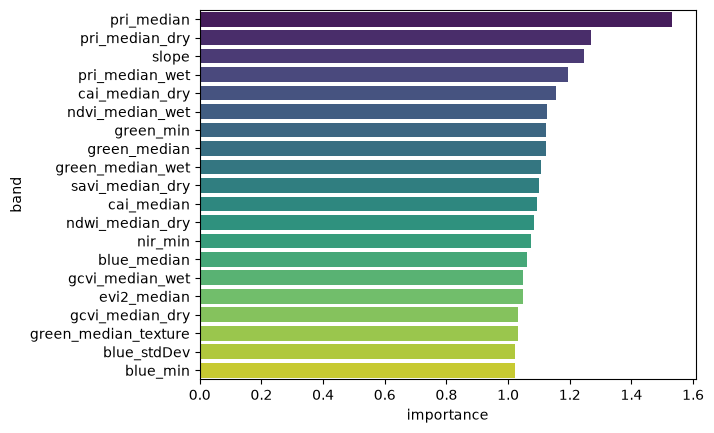

In [54]:
sns.barplot(x='importance', y='band', data=feature_importance_df.head(20), palette='viridis')

Check feature importance in the 16 bands case

In [55]:
_, _,feature_importance_static_df = selector.run_feature_selection(case='static_features',
                                                                   return_importance=True)

Executing Configuration: Static Features (16 total)...
-> Static Features Result | Accuracy: 0.9193 | Weighted F1-Score: 0.9184



/tmp/ipykernel_44549/3842388472.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=feature_importance_static_df, palette='viridis')


<Axes: xlabel='importance', ylabel='band'>

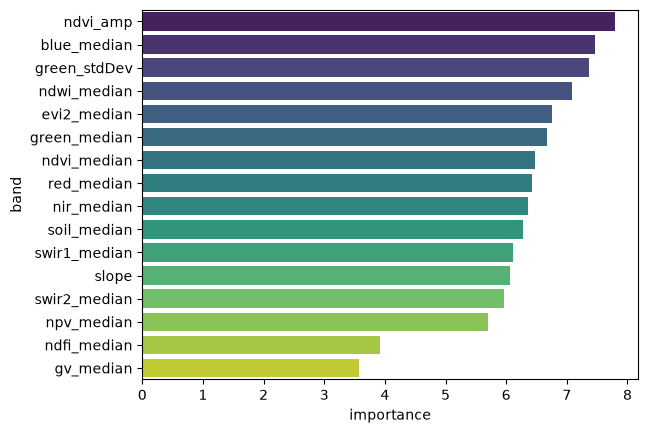

In [56]:
sns.barplot(x='importance', y='band', data=feature_importance_static_df, palette='viridis')

Top 10 bands case

In [57]:
_, _,feature_importance_top10_df = selector.run_feature_selection(case='top_10_features',
                                                                   return_importance=True)

Executing Configuration: Top 10 Features...
-> Top 10 Features Result | Accuracy: 0.9015 | Weighted F1-Score: 0.9007



/tmp/ipykernel_44549/3497154391.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=feature_importance_top10_df, palette='viridis')


<Axes: xlabel='importance', ylabel='band'>

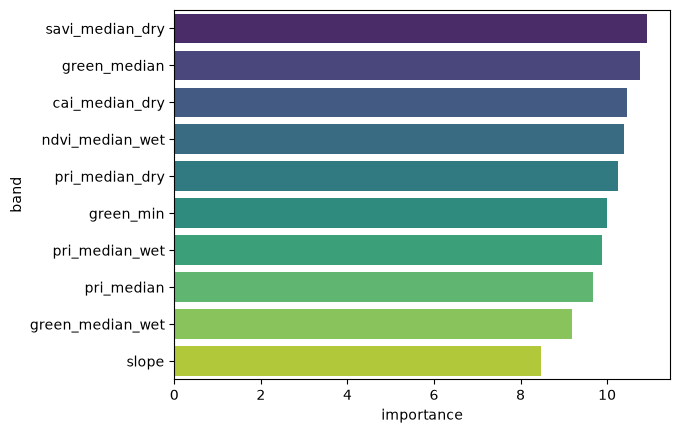

In [58]:
sns.barplot(x='importance', y='band', data=feature_importance_top10_df, palette='viridis')

Features analysis

In [59]:
feature_importance_df['unique_band'] = feature_importance_df['band'].apply(lambda x: x.split('_')[0])

In [60]:
feature_importance_df['unique_band'].nunique()

24

In [61]:
feature_importance_df['unique_band'].unique()

<StringArray>
[      'pri',     'slope',       'cai',      'ndvi',     'green',      'savi',
      'ndwi',       'nir',      'blue',      'gcvi',      'evi2',     'swir1',
       'npv',       'red',     'cloud',     'swir2',     'shade', 'hallcover',
      'sefi',      'soil',      'ndfi',      'wefi',       'gvs',        'gv']
Length: 24, dtype: str

In [62]:
feature_importance_df[feature_importance_df['unique_band'] == 'gvs']

,band,importance,unique_band
91,gvs_stdDev,0.724523,gvs
92,gvs_amp,0.720420,gvs
95,gvs_max,0.691739,gvs
99,gvs_median,0.661245,gvs
101,gvs_median_dry,0.632479,gvs
102,gvs_median_wet,0.615917,gvs
117,gvs_min,0.418538,gvs


In [63]:
feature_importance_df['band_stat'] = feature_importance_df['band'].apply(lambda x: '_'.join(x.split('_')[1:]))

In [64]:
feature_importance_df

,band,importance,unique_band,band_stat
0,pri_median,1.531947,pri,median
1,pri_median_dry,1.267810,pri,median_dry
2,slope,1.245492,slope,
3,pri_median_wet,1.193969,pri,median_wet
4,cai_median_dry,1.154903,cai,median_dry
...,...,...,...,...
114,ndfi_median_dry,0.453363,ndfi,median_dry
115,ndfi_min,0.441407,ndfi,min
116,npv_stdDev,0.434526,npv,stdDev
117,gvs_min,0.418538,gvs,min


In [77]:
feature_stats_df = feature_importance_df.groupby('unique_band')['band_stat'].unique().reset_index()

In [78]:
feature_stats_df

,unique_band,band_stat
0,blue,"[median, stdDev, min, median_wet, median_dry]"
1,cai,"[median_dry, median, stdDev]"
2,cloud,"[median_dry, median, median_wet, min, max, amp, stdDev]"
3,evi2,"[median, median_dry, amp, stdDev, median_wet]"
4,gcvi,"[median_wet, median_dry, stdDev, median]"
5,green,"[min, median, median_wet, median_texture, stdDev, median_dry]"
6,gv,"[max, amp, median_wet, median, median_dry, stdDev, min]"
7,gvs,"[stdDev, amp, max, median, median_dry, median_wet, min]"
8,hallcover,"[stdDev, median]"
9,ndfi,"[max, amp, median, stdDev, median_wet, median_dry, min]"


In [66]:
pd.set_option('display.max_colwidth', None)

In [82]:
# feature_stats_df.to_csv('data/band_stats_categories_df.csv', index=False)

In [83]:
feature_stats_df

,unique_band,band_stat
0,blue,"[median, stdDev, min, median_wet, median_dry]"
1,cai,"[median_dry, median, stdDev]"
2,cloud,"[median_dry, median, median_wet, min, max, amp, stdDev]"
3,evi2,"[median, median_dry, amp, stdDev, median_wet]"
4,gcvi,"[median_wet, median_dry, stdDev, median]"
5,green,"[min, median, median_wet, median_texture, stdDev, median_dry]"
6,gv,"[max, amp, median_wet, median, median_dry, stdDev, min]"
7,gvs,"[stdDev, amp, max, median, median_dry, median_wet, min]"
8,hallcover,"[stdDev, median]"
9,ndfi,"[max, amp, median, stdDev, median_wet, median_dry, min]"


In [72]:
feature_importance_df = feature_importance_df.merge(feature_stats_df[['unique_band','band_category']])

KeyError: "['band_category'] not in index"

In [ ]:
feature_importance_df

In [ ]:
feature_importance_df['band_category'].value_counts()

Feature Correlation

In [ ]:
feature_importance_df

In [ ]:
# list(corr_matrix.columns)

['soil_median_dry',
 'gvs_median_dry',
 'cai_stdDev',
 'shade_median_dry',
 'savi_median_wet',
 'pri_median_dry',
 'ndvi_stdDev',
 'swir2_min',
 'npv_median_wet',
 'npv_stdDev',
 'wefi_amp',
 'shade_median',
 'gvs_amp',
 'soil_median',
 'gv_amp',
 'shade_stdDev',
 'cai_median',
 'hallcover_median',
 'cloud_amp',
 'cloud_median',
 'nir_median',
 'evi2_stdDev',
 'gvs_median',
 'red_min',
 'ndvi_median',
 'ndfi_stdDev',
 'slope',
 'savi_median',
 'gcvi_stdDev',
 'green_min',
 'npv_max',
 'gcvi_median_dry',
 'npv_min',
 'evi2_median_wet',
 'blue_median_dry',
 'swir2_median_wet',
 'red_median_wet',
 'nir_stdDev',
 'swir1_stdDev',
 'soil_amp',
 'shade_median_wet',
 'red_median_dry',
 'wefi_median_wet',
 'sefi_stdDev',
 'cloud_median_wet',
 'hallcover_stdDev',
 'npv_amp',
 'evi2_amp',
 'gvs_stdDev',
 'soil_stdDev',
 'ndwi_stdDev',
 'savi_median_dry',
 'green_median_wet',
 'blue_min',
 'blue_median',
 'cai_median_dry',
 'blue_median_wet',
 'shade_amp',
 'gv_min',
 'ndvi_amp',
 'ndwi_median',
 

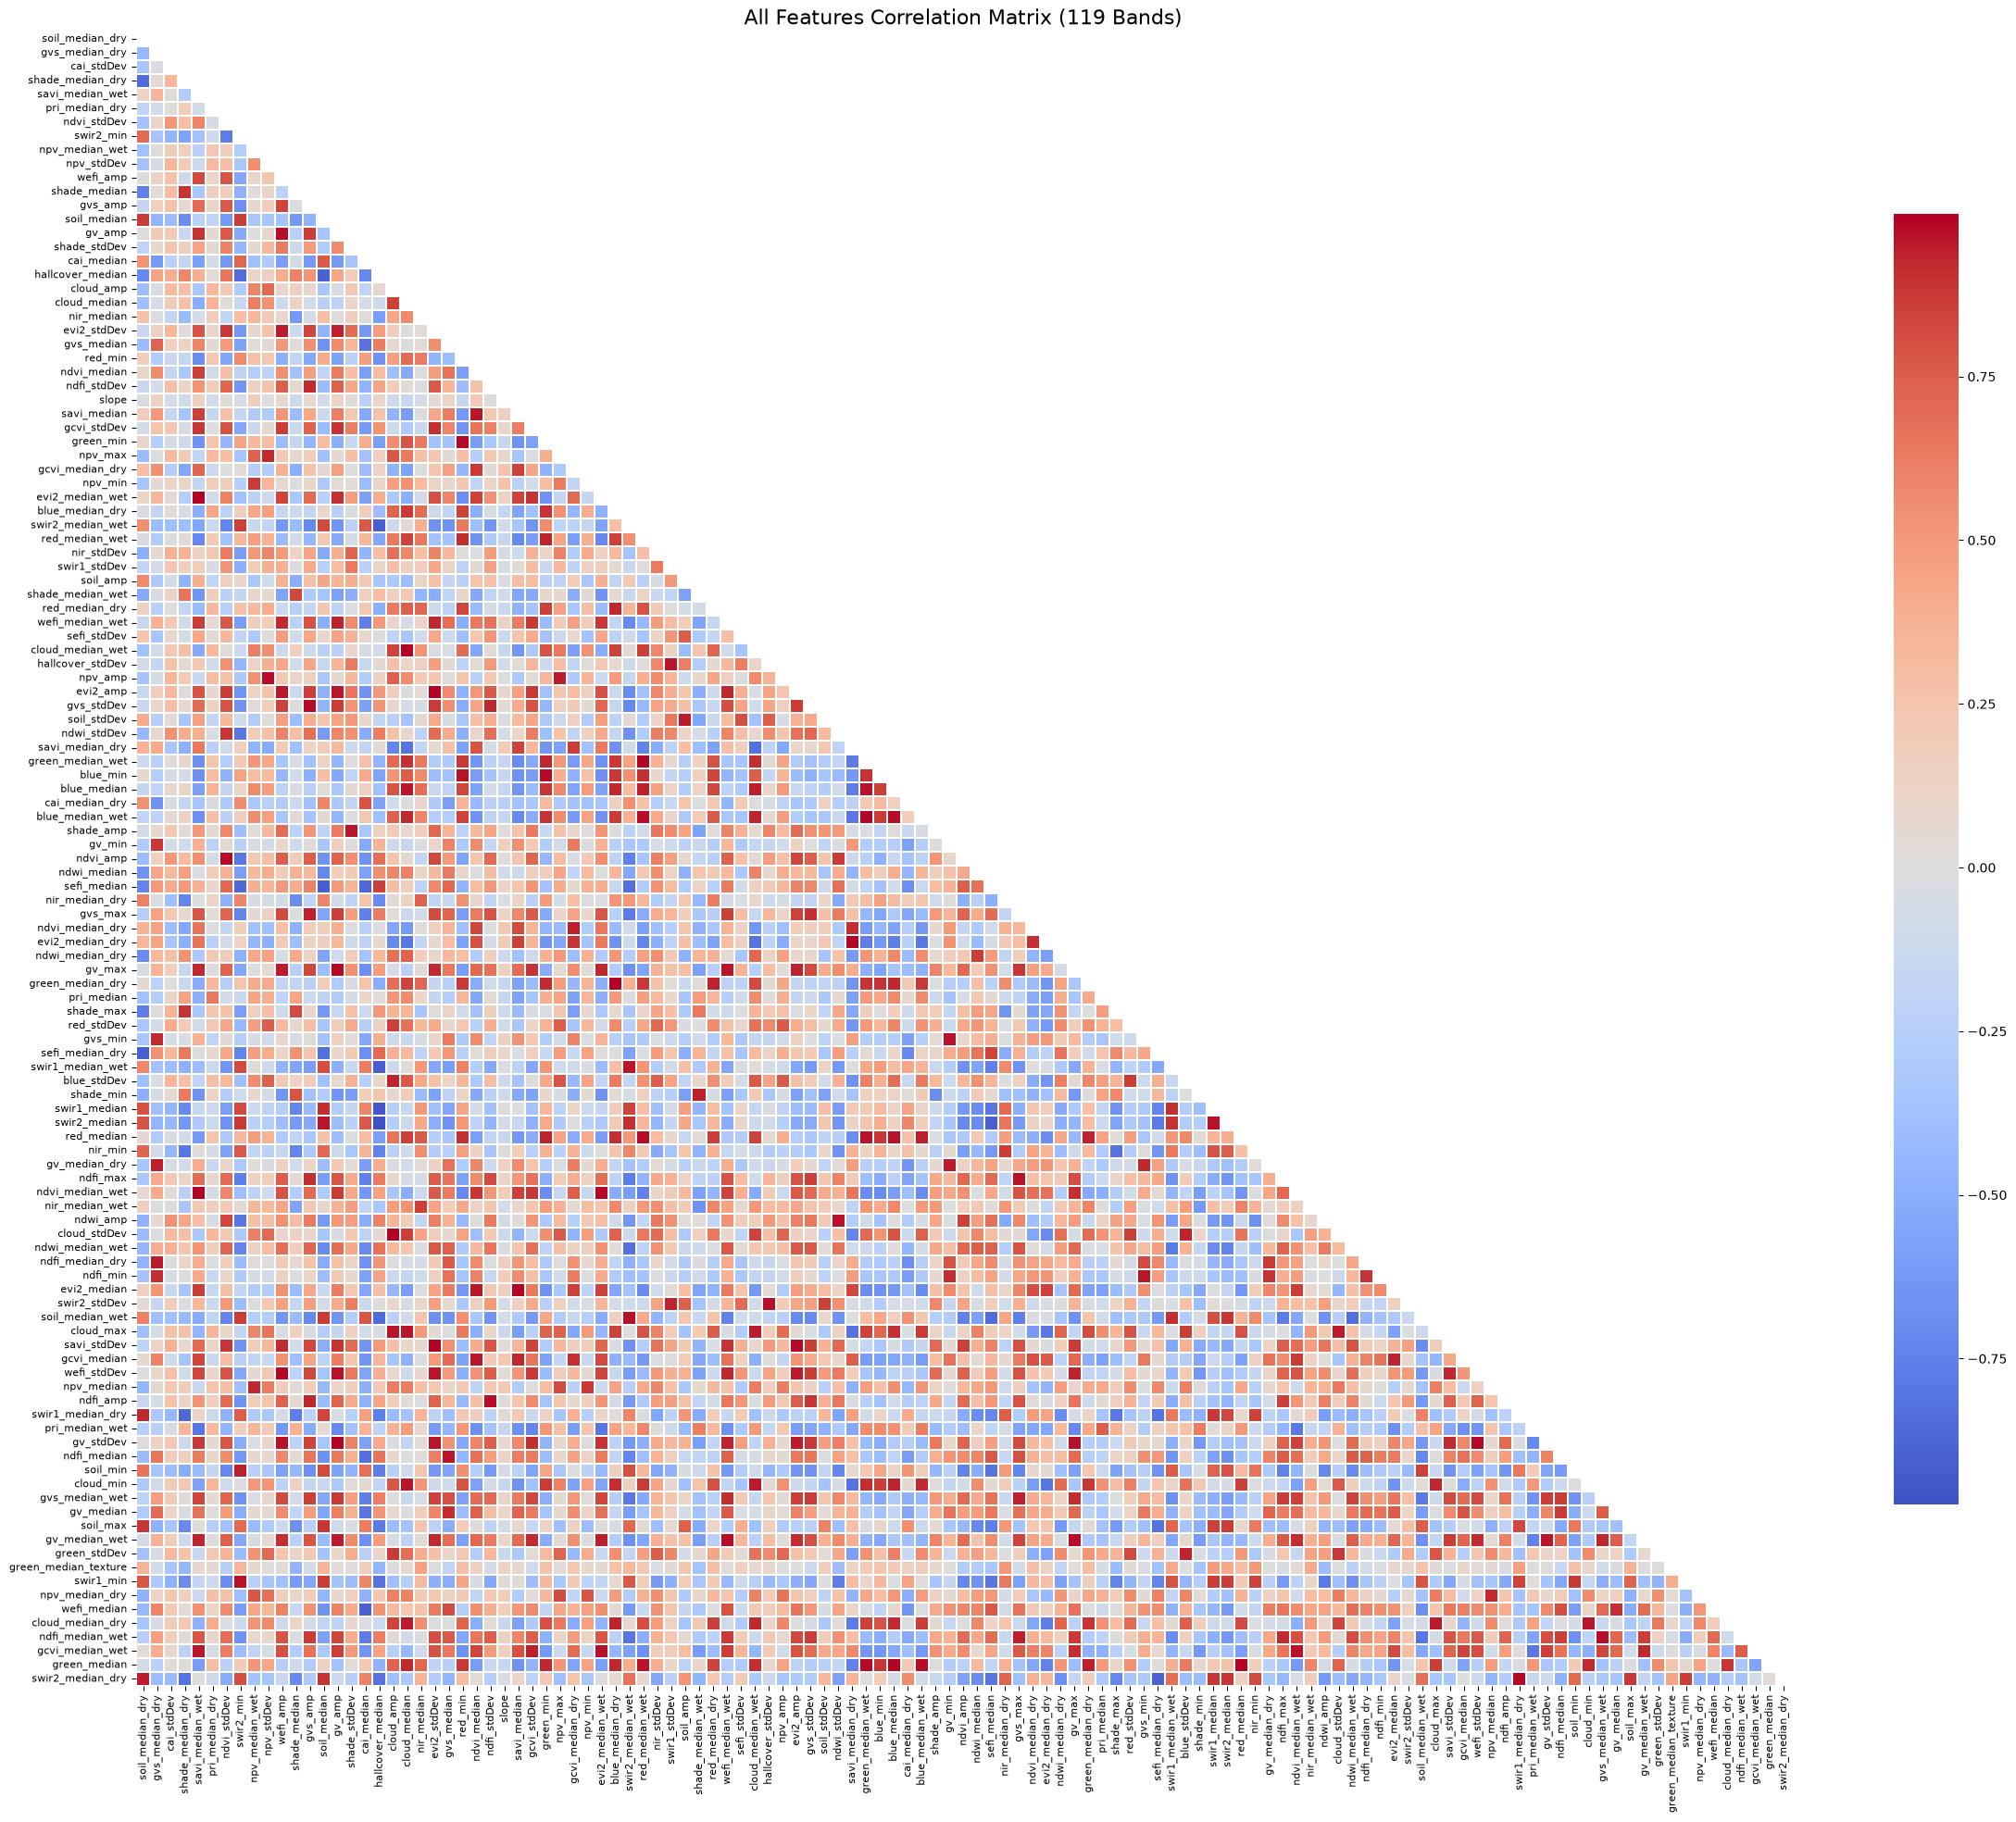

In [28]:
# matrix_all_features = corr_matrices['All Features']

# 2. Set up a much larger figure for the 100+ features
plt.figure(figsize=(24, 20))

# 3. Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Generate the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=.1,               # Thinner lines for a denser grid
    cbar_kws={"shrink": .75},
    annot=False,                 # Turned off because 119x119 numbers won't fit
    xticklabels=True, 
    yticklabels=True
)

# Make the labels smaller so they don't overlap as much
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.title('All Features Correlation Matrix (119 Bands)', fontsize=16)
plt.tight_layout()
plt.show()

In [49]:
corr_matrix

,soil_median_dry,gvs_median_dry,cai_stdDev,shade_median_dry,savi_median_wet,pri_median_dry,ndvi_stdDev,swir2_min,npv_median_wet,npv_stdDev,...,green_stdDev,green_median_texture,swir1_min,npv_median_dry,wefi_median,cloud_median_dry,ndfi_median_wet,gcvi_median_wet,green_median,swir2_median_dry
soil_median_dry,1.000000,-0.432085,-0.342104,-0.856632,0.120174,-0.198364,-0.362927,0.711813,-0.374646,-0.366262,...,-0.374864,0.365477,0.782169,-0.485172,-0.427813,-0.341706,-0.254807,0.034041,-0.065374,0.947757
gvs_median_dry,-0.432085,1.000000,-0.018466,0.052518,0.355819,-0.086731,0.102187,-0.355849,0.007348,-0.039635,...,-0.038512,-0.081435,-0.306931,0.120062,0.596147,-0.044150,0.461852,0.392660,-0.237896,-0.407417
cai_stdDev,-0.342104,-0.018466,1.000000,0.338218,0.038501,0.018169,0.512341,-0.460448,0.178316,0.343052,...,0.328396,-0.337203,-0.480618,0.239554,0.214275,0.194046,0.187043,0.090293,0.034121,-0.422293
shade_median_dry,-0.856632,0.052518,0.338218,1.000000,-0.278979,0.188845,0.286278,-0.562697,0.156423,0.202519,...,0.261899,-0.447318,-0.690079,0.151200,0.038226,0.226644,0.038853,-0.220171,0.019807,-0.816873
savi_median_wet,0.120174,0.355819,0.038501,-0.278979,1.000000,-0.084037,0.590832,-0.369013,-0.232549,-0.116043,...,-0.153712,0.072669,-0.172119,-0.125167,0.541437,-0.485633,0.778245,0.959780,-0.606715,0.012118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cloud_median_dry,-0.341706,-0.044150,0.194046,0.226644,-0.485633,0.399959,-0.023005,-0.106818,0.522772,0.563804,...,0.645614,0.094011,-0.219443,0.581826,0.188167,1.000000,-0.095639,-0.421218,0.884456,-0.261913
ndfi_median_wet,-0.254807,0.461852,0.187043,0.038853,0.778245,0.087714,0.690372,-0.670879,0.075108,0.104284,...,0.139796,-0.042707,-0.524465,0.182010,0.708880,-0.095639,1.000000,0.760111,-0.338213,-0.360792
gcvi_median_wet,0.034041,0.392660,0.090293,-0.220171,0.959780,-0.053309,0.620602,-0.414220,-0.208827,-0.049073,...,-0.115896,0.001789,-0.238699,-0.048396,0.592008,-0.421218,0.760111,1.000000,-0.564049,-0.077873
green_median,-0.065374,-0.237896,0.034121,0.019807,-0.606715,0.291396,-0.227690,0.208921,0.518825,0.434426,...,0.570365,0.245711,0.088509,0.453738,0.002851,0.884456,-0.338213,-0.564049,1.000000,0.037966


In [41]:
# 1. Define your correlation threshold (e.g., 0.90 means 90% correlated)
threshold = 0.90

# 2. Get the absolute values of the correlation matrix 
# (since strong negative correlation is just as redundant as strong positive)
abs_corr_matrix = corr_matrix.abs()

# 3. Apply a mask to get only the upper triangle, ignoring the diagonal (self-correlation)
upper_triangle = abs_corr_matrix.where(
    np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool)
)

# 4. Unstack the matrix, drop NaNs, and filter by the threshold
high_corr_pairs = (
    upper_triangle.unstack()
    .dropna()
    .loc[lambda x: x > threshold]
    .sort_values(ascending=False)
    .reset_index()
)

# 5. Clean up the columns for a nice display
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Absolute Correlation']

print(f"Found {len(high_corr_pairs)} pairs of highly correlated features (> {threshold})\n")

# Display all of them (or change to .head(20) if the list is too long)
display(high_corr_pairs)

Found 198 pairs of highly correlated features (> 0.9)



,Feature 1,Feature 2,Absolute Correlation
0,evi2_median_wet,savi_median_wet,0.998905
1,evi2_median,savi_median,0.998415
2,evi2_median_dry,savi_median_dry,0.998227
3,blue_median_wet,green_median_wet,0.991821
4,savi_stdDev,evi2_stdDev,0.990490
...,...,...,...
193,evi2_median_wet,gv_amp,0.901176
194,gcvi_median,gcvi_median_dry,0.900994
195,swir1_median,swir1_median_wet,0.900350
196,hallcover_median,soil_median,0.900068


Out of 119 total features, 96 are highly correlated with at least one other feature.


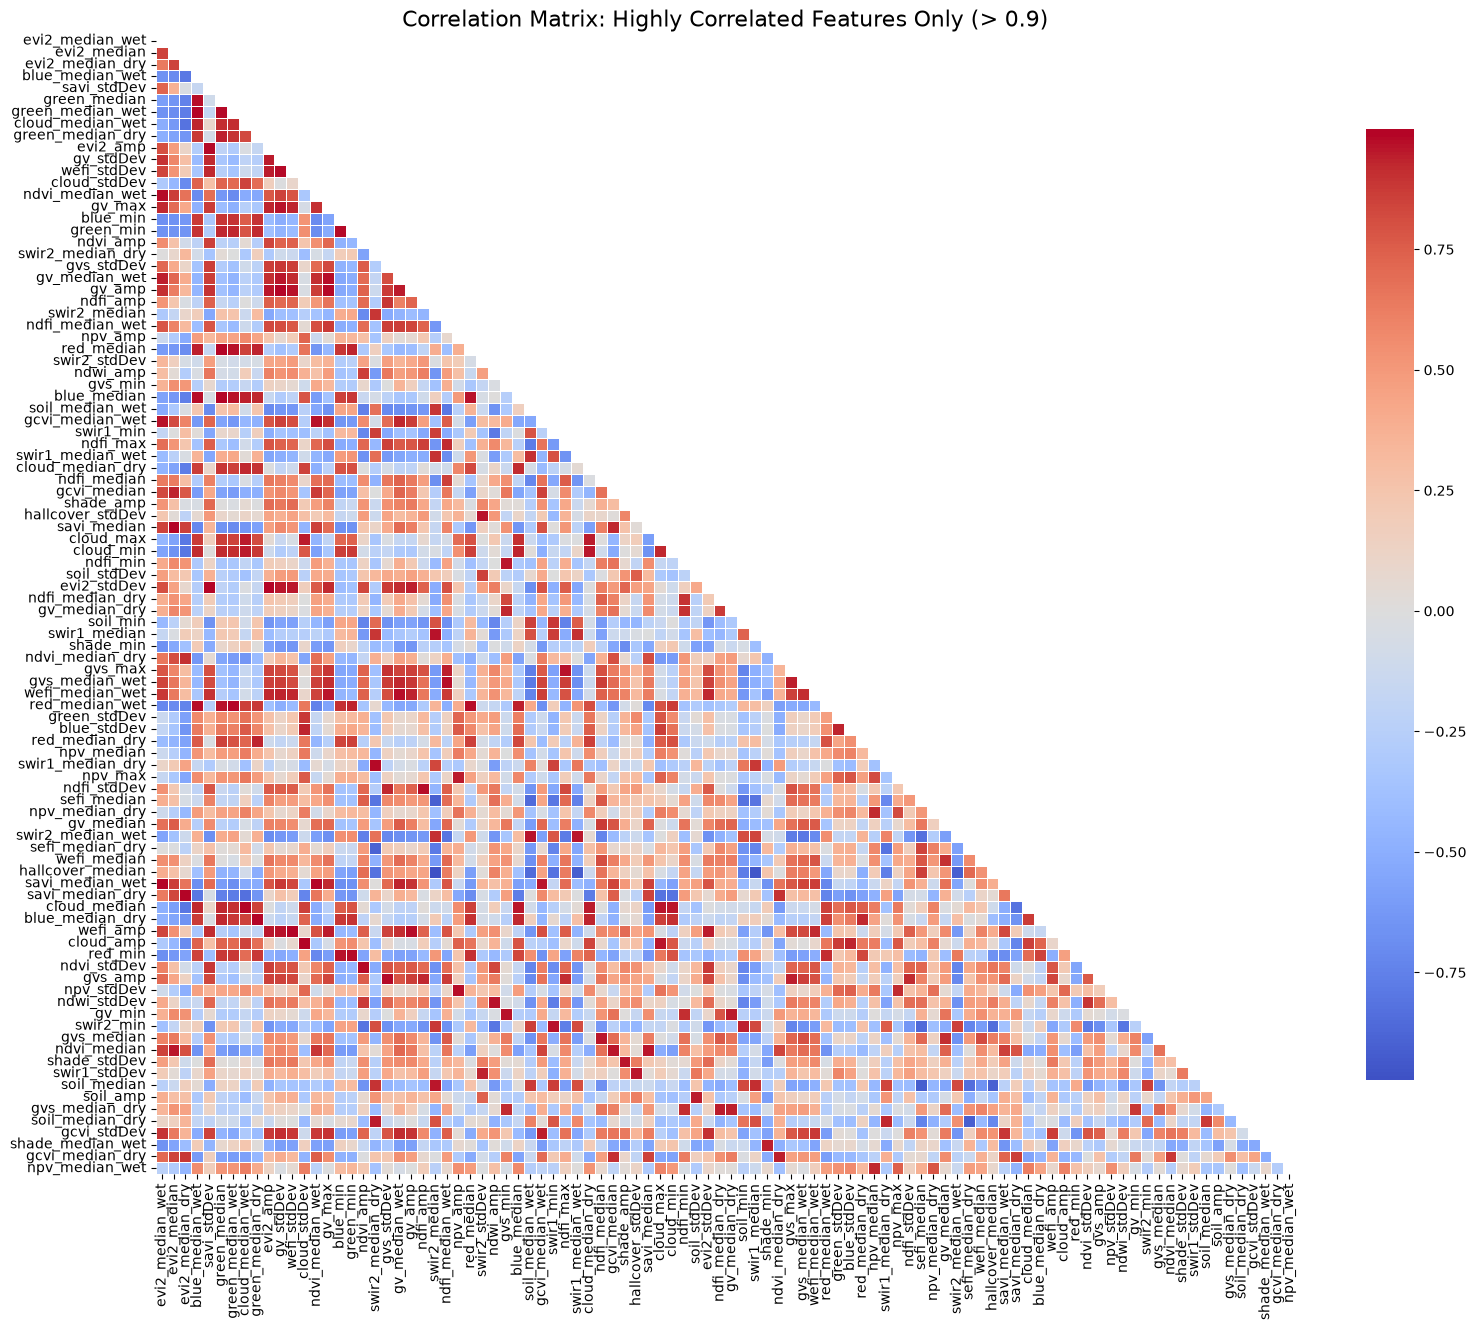

In [43]:
# 1. Extract unique features that appear in the highly correlated pairs
problem_features = pd.concat([
    high_corr_pairs['Feature 1'], 
    high_corr_pairs['Feature 2']
]).unique()

print(f"Out of 119 total features, {len(problem_features)} are highly correlated with at least one other feature.")

# 2. Subset the original correlation matrix to only include these features
subset_matrix = corr_matrix.loc[problem_features, problem_features]

# 3. Plot the subset matrix
plt.figure(figsize=(16, 14))

# Create a mask for the upper triangle
mask_subset = np.triu(np.ones_like(subset_matrix, dtype=bool))

# Generate the heatmap
sns.heatmap(
    subset_matrix, 
    mask=mask_subset, 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot=False,  # You can change this to True if the number of features is small enough to read the text
    xticklabels=True, 
    yticklabels=True
)

# Rotate x labels for better readability
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)

plt.title(f'Correlation Matrix: Highly Correlated Features Only (> {threshold})', fontsize=16)
plt.tight_layout()
plt.show()

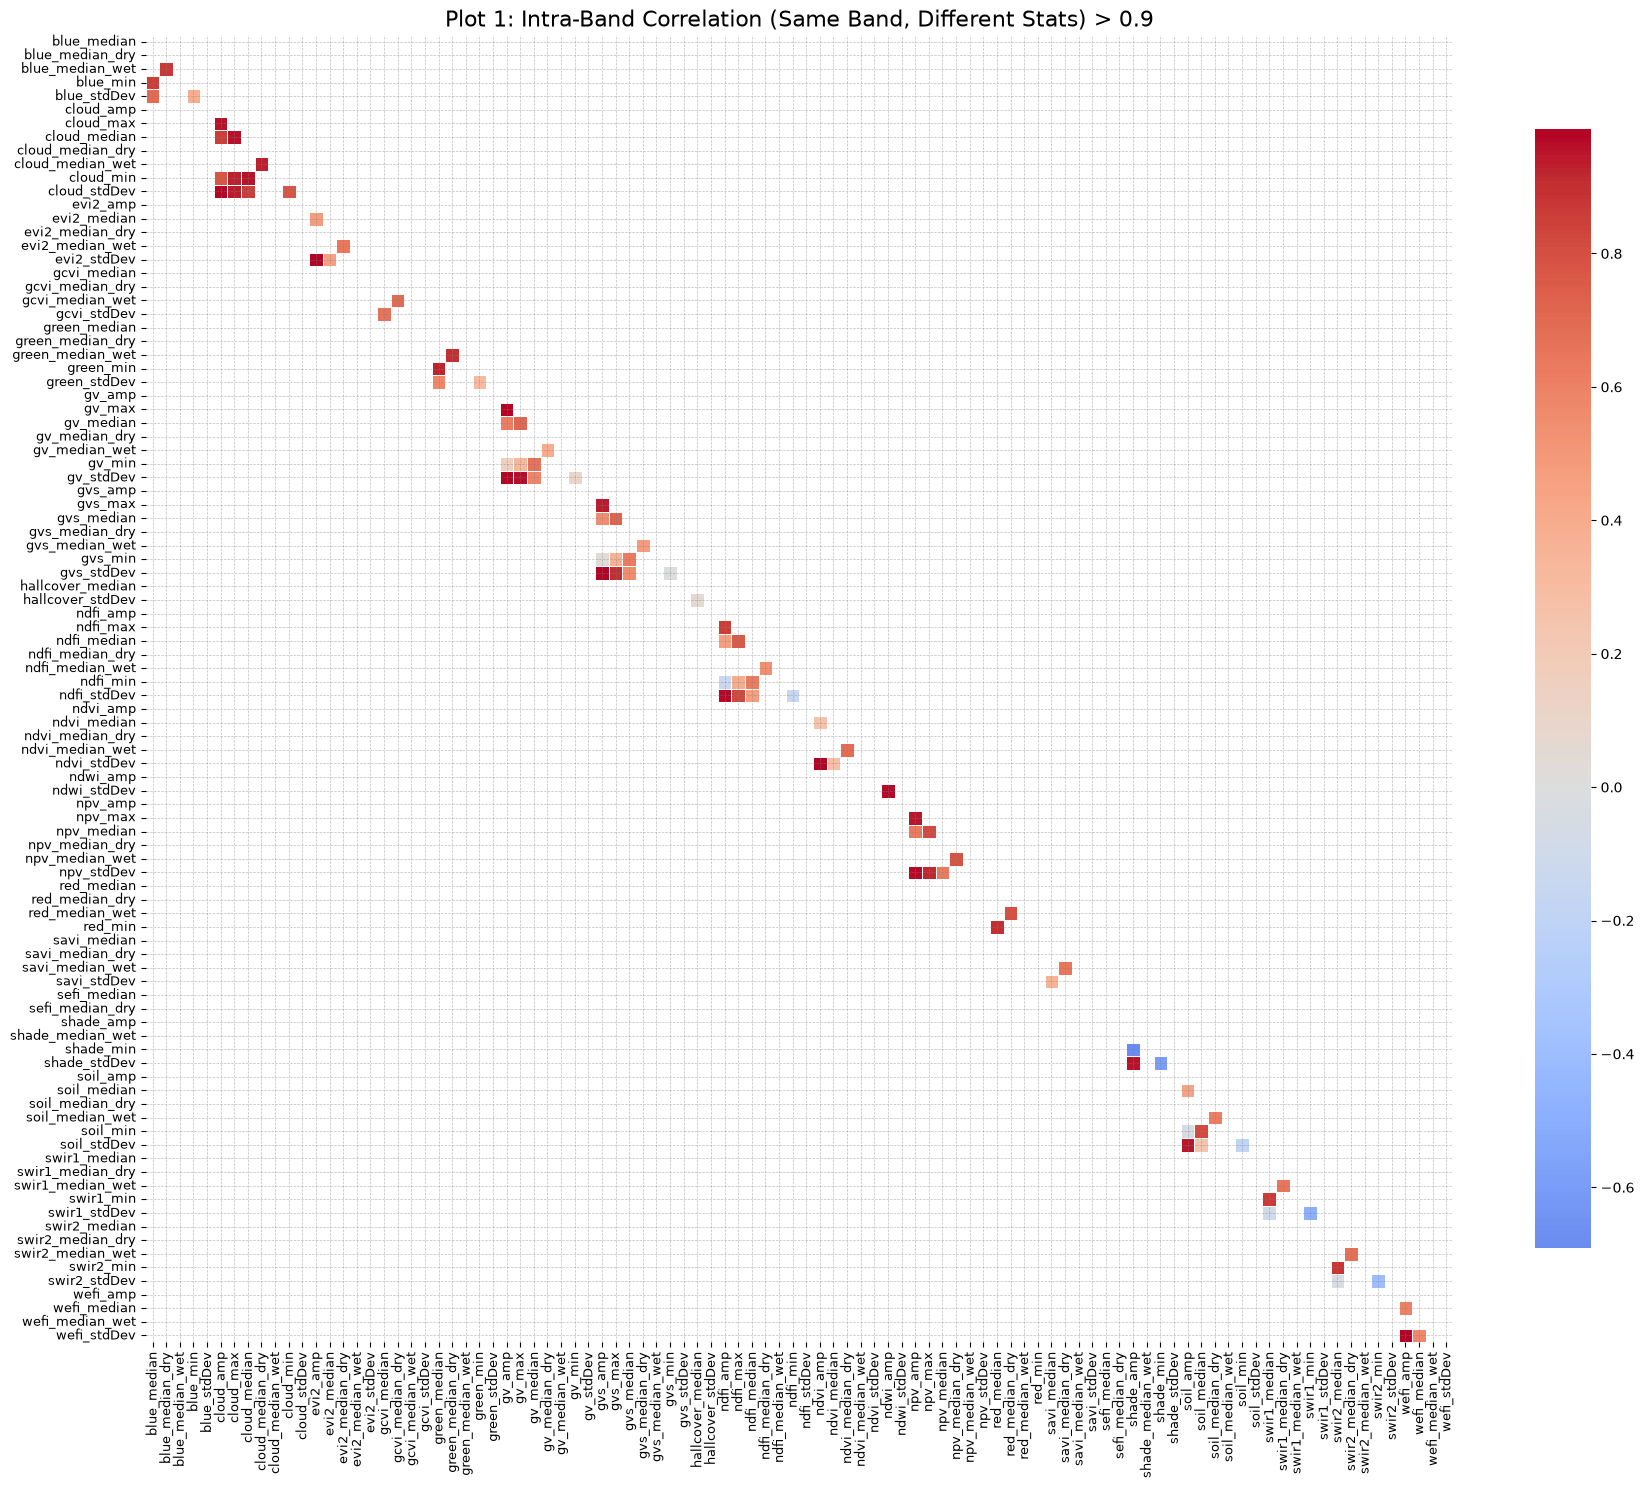

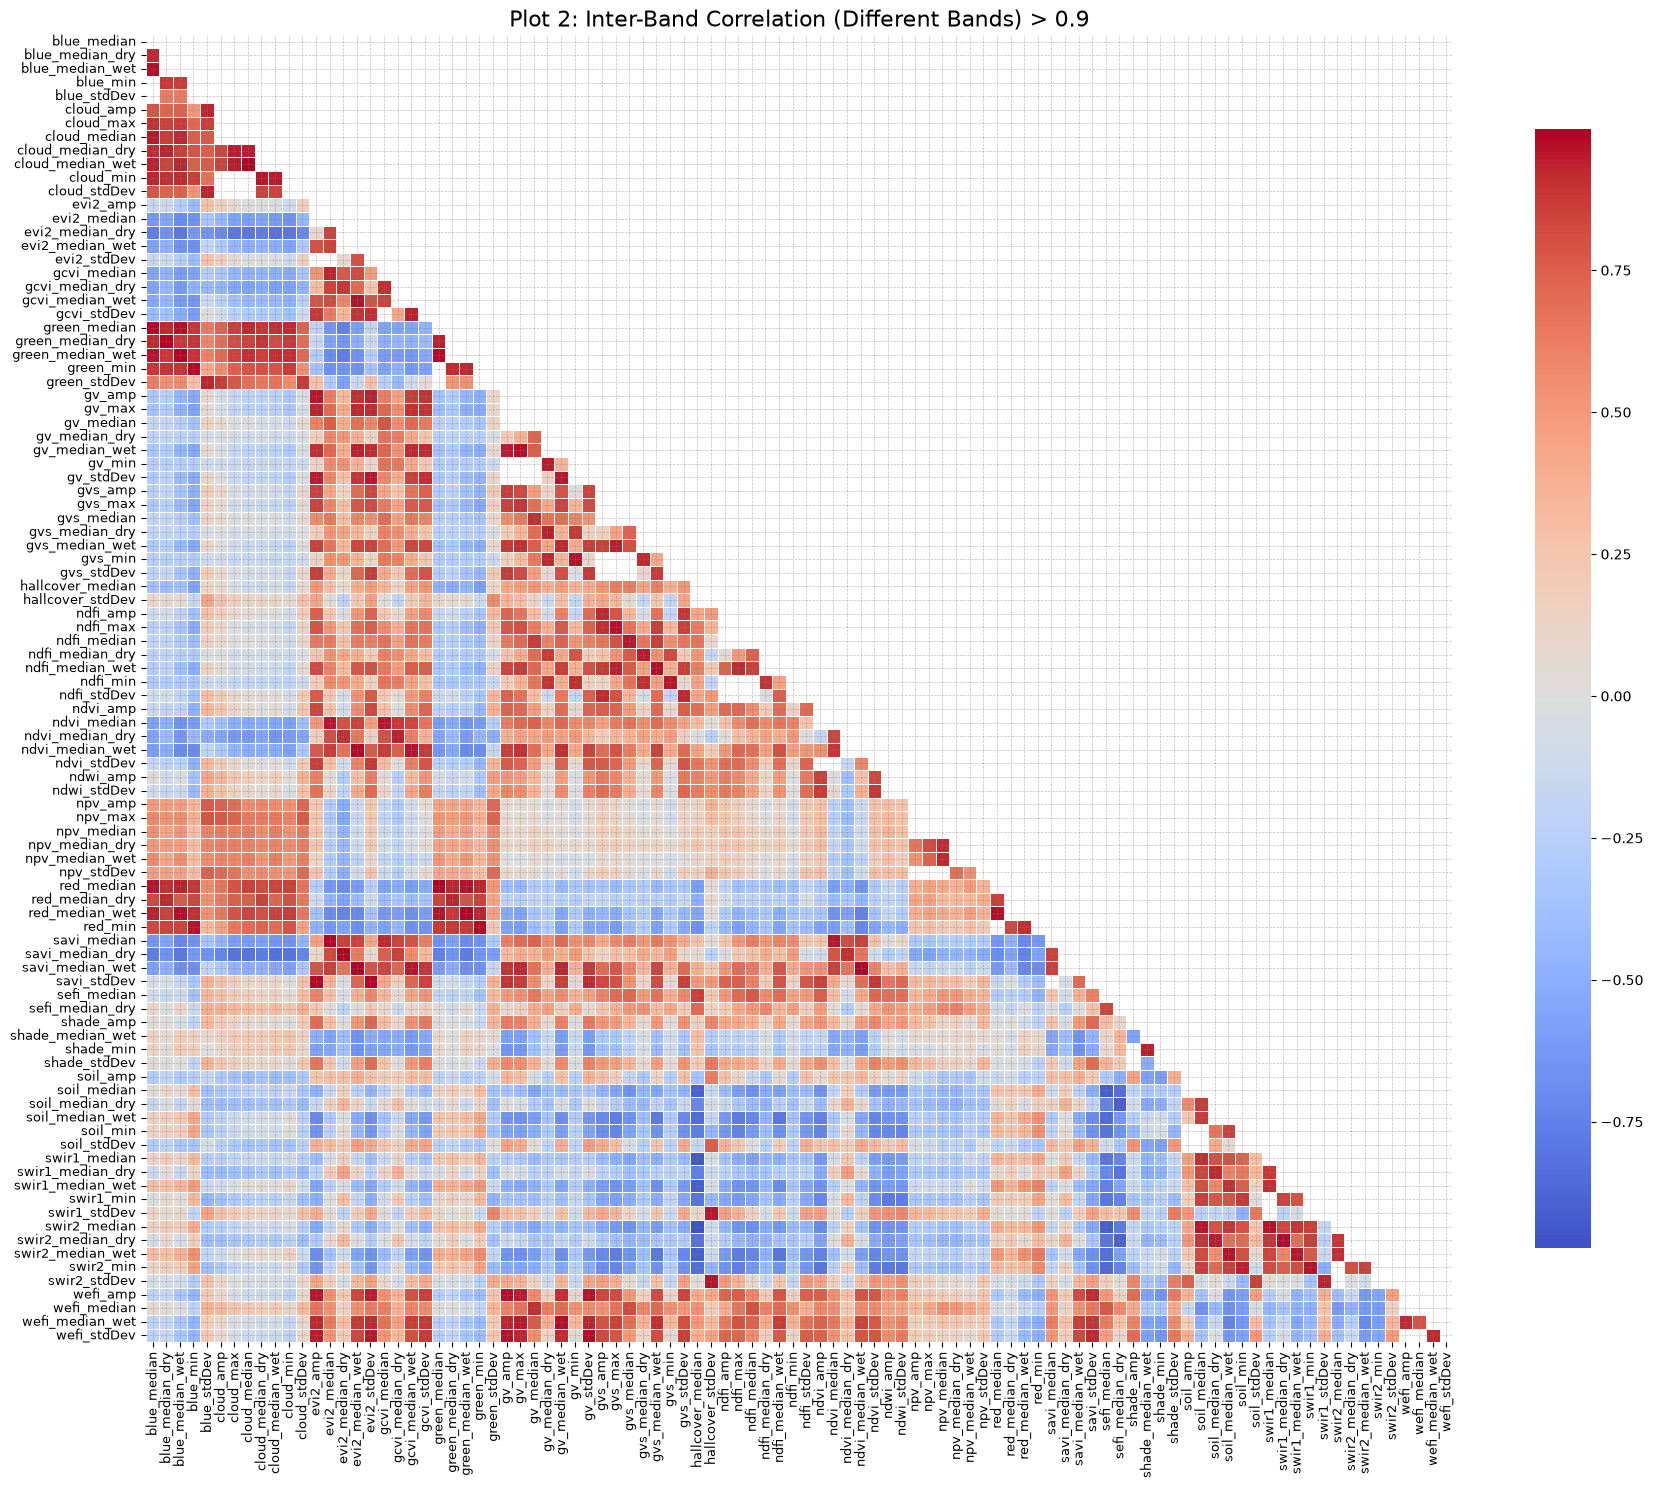

In [48]:
# Helper function to extract the base band name (e.g., 'red_median' -> 'red')
def get_base_band(feat_name):
    # Splits by the last underscore. If no underscore exists, returns the original name.
    return feat_name.rsplit('_', 1)[0] if '_' in feat_name else feat_name

# 3. Initialize custom masks. True = HIDE the square, False = SHOW the square
# We start by hiding everything, then reveal what we want.
mask_intra_band = np.ones_like(subset_matrix, dtype=bool)
mask_inter_band = np.ones_like(subset_matrix, dtype=bool)

# 4. Loop through the grid and assign the masks
for i, row_feat in enumerate(problem_features):
    for j, col_feat in enumerate(problem_features):
        
        # Only process the lower triangle to prevent duplicate information
        if i > j:
            band1 = get_base_band(row_feat)
            band2 = get_base_band(col_feat)
            
            if band1 == band2:
                # Same band -> Show in Intra-band plot
                mask_intra_band[i, j] = False
            else:
                # Different bands -> Show in Inter-band plot
                mask_inter_band[i, j] = False

# =========================================================
# PLOT 1: INTRA-BAND (Same Band, Different Stats)
# =========================================================
plt.figure(figsize=(18, 16))
ax1 = sns.heatmap(
    subset_matrix, 
    mask=mask_intra_band, 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    xticklabels=True, 
    yticklabels=True
)

# Add dashed reference grid lines across the masked area
ax1.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.title(f'Plot 1: Intra-Band Correlation (Same Band, Different Stats) > {threshold}', fontsize=16)
plt.xticks(fontsize=9, rotation=90)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: INTER-BAND (Different Bands)
# =========================================================
plt.figure(figsize=(18, 16))
ax2 = sns.heatmap(
    subset_matrix, 
    mask=mask_inter_band, 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    xticklabels=True, 
    yticklabels=True
)

# Add dashed reference grid lines across the masked area
ax2.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.title(f'Plot 2: Inter-Band Correlation (Different Bands) > {threshold}', fontsize=16)
plt.xticks(fontsize=9, rotation=90)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()